# Static IRS and IPM on one registered source grid

This notebook compares inverse ray shooting (IRS) and inverse polygon mapping
(IPM) without changing the lens realization, source-plane aperture, or pixel
grid.  The CUDA run uses the production $10^7$-ray IPM map and a substantially
larger $2\times10^8$ IRS sample on the same $1024^2$ source plane.  The unequal
budgets are intentional. They show why polygon-area deposition reaches a
smooth point-source map with far fewer image-plane samples than stochastic
ray counting.

The final panel is $-2.5\log_{10}(\mu_{\rm IRS}/\mu_{\rm IPM})$ in magnitudes.
No Gaussian blur or finite-source convolution is used.  Scale bars and fixed
map normalization make spatial differences directly comparable.


In [1]:
from pathlib import Path
import numpy as np
import torch
from matplotlib import pyplot as plt
from astropy.cosmology import FlatLambdaCDM
import microcaustics as mc
import microcaustics.plotting as mcp

plt.rcParams.update(mcp.publication_style())
capabilities = mc.RuntimeCapabilities.detect()
use_cuda = capabilities.cuda_available
runtime_config = mc.RuntimeConfig(
    profiling="detailed",  # opt in to synchronized component timings
    device="cuda" if use_cuda else "cpu",
    backend="triton" if use_cuda and capabilities.triton_importable else "auto",
    dtype=torch.float32,
    strict_backend=use_cuda and capabilities.triton_importable,
)
print(mcp.runtime_description())


Python 3.11.15 | PyTorch 2.12.1+cu130 | Windows AMD64 | CUDA 13.0, NVIDIA GeForce RTX 5070 Ti, compute capability 12.0


In [2]:
stars = mc.PointMassField(
        x_uas=torch.tensor([-0.8, 0.2, 0.9]),
        y_uas=torch.tensor([0.4, -0.5, 0.1]),
        einstein_radius_uas=torch.tensor([0.24, 0.19, 0.21]),
)
region = mc.PlaneRegion((5.0, 5.0))
resolution = 1024 if use_cuda else 256
grid = mc.PlaneGrid((resolution, resolution), (2.0, 2.0))
system = mc.MicrolensingSystem(
    macro=mc.MacroLens(convergence=0.2, shear=0.08),
    distances=mc.LensingDistances(8.0e24, 1.6e25, 9.0e24),
    stars=stars, source_grid=grid, lens_region=region, runtime=runtime_config,
)
simulation = system.realize().simulation  # advanced method diagnostics below
ipm_rays = 10_000_000 if use_cuda else 262_144
irs_rays = 200_000_000 if use_cuda else 4_194_304
print(
    f"IPM N={ipm_rays:,}; IRS N={irs_rays:,}; "
    f"source={resolution} x {resolution}"
)


IPM N=10,000,000; IRS N=200,000,000; source=1024 x 1024


In [3]:
ipm = simulation.magnification_map(
    region,
    grid,
    method=mc.IPMConfig(
        rays=ipm_rays,
        scout_ratio=2,
        refinement=2,
        virtual_refinement=4,
        tiled=False,
        far_field_approx=mc.FarFieldApproxConfig(enabled=False),
    ),
)
tiled_ipm = simulation.magnification_map(
    region,
    grid,
    method=mc.production_ipm_config(
        dynamic=False, rays=ipm_rays,
        far_field_approx=mc.FarFieldApproxConfig(enabled=False),
    ),
)
irs = simulation.magnification_map(
    region,
    grid,
    method=mc.IRSConfig(
        rays=irs_rays,
        far_field_approx=mc.FarFieldApproxConfig(enabled=False),
    ),
)
comparison = mc.compare_magnification_maps(irs.values, ipm.values)
print("Full-field IPM steady time [s]:", ipm.timing.delivered_seconds)
print("Source-scouted tiled IPM steady time [s]:", tiled_ipm.timing.delivered_seconds)
print("IRS steady time [s]:", irs.timing.delivered_seconds)
print(comparison)


Full-field IPM steady time [s]: 3.6808147999690846
Source-scouted tiled IPM steady time [s]: 1.7357424999936484
IRS steady time [s]: 1.8130899000097997
MapComparison(linear_nrmse=0.044387138176166234, fractional_nrmse=0.06005936200385346, rmse_mmag=65.37722995922327, bias_mmag=1.9673654358749306, p95_absolute_mmag=148.75655502815763, valid_pixels=1048576)


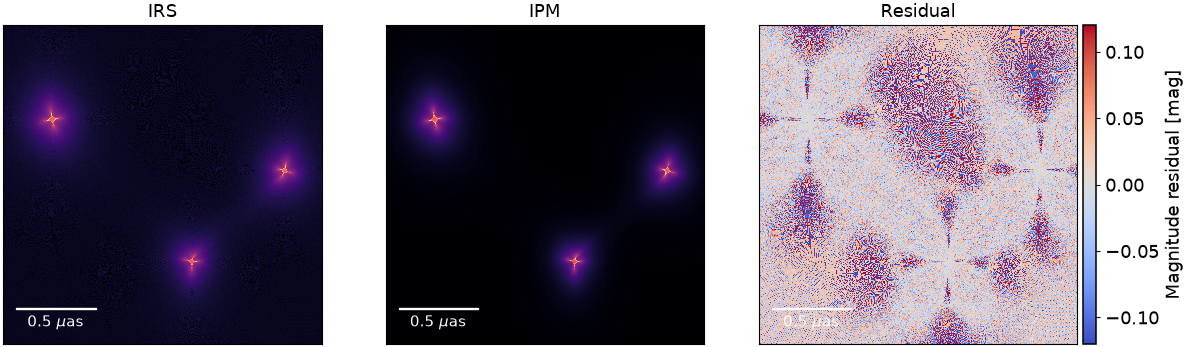

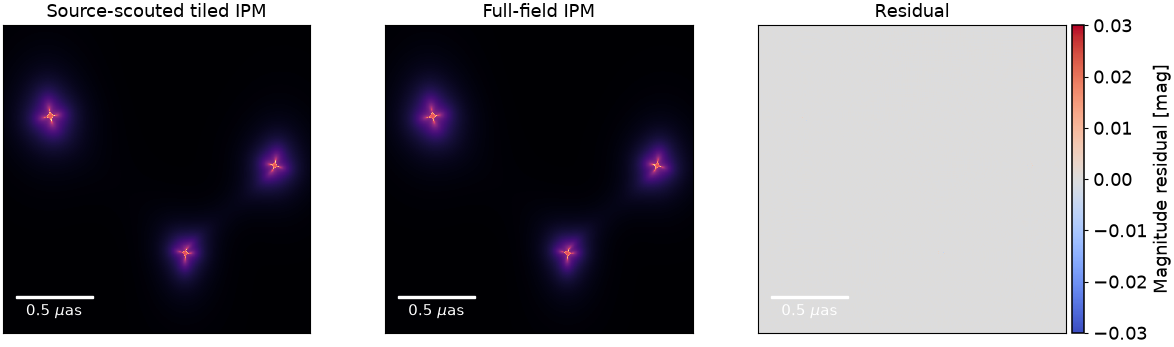

In [4]:
figure, axes = mcp.plot_map_comparison(
    irs,
    ipm,
    residual="magnitude",
    residual_limit=0.12,
    scale_bar_uas=0.5,
    show_axes=False,
)
axes[0].set_title("IRS")
axes[1].set_title("IPM")
axes[2].set_title("Residual")
figure.set_size_inches(12.8, 3.8)
figure.tight_layout()

figure, axes = mcp.plot_map_comparison(
    tiled_ipm, ipm, residual="magnitude", residual_limit=0.03,
    scale_bar_uas=0.5, show_axes=False,
)
axes[0].set_title("Source-scouted tiled IPM")
axes[1].set_title("Full-field IPM")
axes[2].set_title("Residual")
figure.set_size_inches(12.8, 3.8)
figure.tight_layout()


## How tiled IPM selects and maps cells

This cell reproduces Figure 3 of the paper exactly from its compact Q2237
image-B diagnostics and the same publication renderer. The retained scout
cells use $k=2$. The selected fine cell is evaluated at the true $r+1$ by
$r+1$ nodes, reconstructed on the virtual $v=4$ lattice, split into mapped
triangles, and clipped against the native source-pixel grid. The PNG is
regenerated below rather than loaded as a pre-rendered figure.

The scout controls are deliberately separate. `scout_ratio` ($k$) sets the
coarse discovery-grid spacing. `scout_halo_pixels` expands the source
aperture before the mapped-cell test, whereas `scout_dilation_cells` adds a
support ring to the selected mask in the lens plane. `scout_trace_centers`
adds mapped cell-center queries. The validated dynamic preset uses $k=2$,
zero source-pixel halo, one cell of lens-plane dilation, and center probes.
A standalone static map defaults to the complete $k=1$ scout.

## Apertures, light loss, and the controls that change accuracy

`light_loss` is an aperture-sizing tolerance used by the rectangular lens-region estimate. It is not a request to discard that fraction of the final map or light curve. A finite rectangular image-plane aperture can nevertheless omit rays and caustics outside its boundary. The production tiled calculation therefore uses the complete circular stellar field and selects only cells that map into the requested source aperture. In the training examples, the circular lens diameter is conservatively set to 1.5 times the diagonal of the 1%-light-loss rectangular estimate. This multiplicative safety scale increases the physical stellar aperture. Increasing it adds stars and cost, while convergence should leave the central source map unchanged.

The main numerical controls are deliberately independent:

| Control | Meaning | Primary effect |
|, |, |, |
| source field of view and pixel shape | Physical map aperture and requested output sampling | Scientific coverage, memory, and required ray density |
| lens region, `light_loss`, and safety scale | Physical point-mass aperture | Boundary bias, star count, and cost |
| stellar mass function, compact fraction, positions, velocities | Physical microlens realization | Caustic density and temporal evolution |
| `rays` ($N$) | Requested base image-plane cell budget | Map sampling and runtime |
| `scout_ratio` ($k$) | Coarsening used only to discover source-mapping cells | Scout cost and completeness |
| `refinement` ($r$) | True lens-equation subdivision inside retained cells | Accuracy and lens evaluations |
| `virtual_refinement` ($v$) | Interpolated polygon subdivision after tracing | Rasterization accuracy without new lens evaluations |
| `tiled` | Use the source scout rather than all image-plane cells | Usually the largest spatial saving |
| `scout_halo_pixels`, `scout_dilation_cells` | Enlarge retained source/lens support | Completeness versus extra cells |
| `dual_scout_scalar_correction` | One frame-zero $k=1$ normalization for dynamic $k=2$ runs | Removes the small tiled flux offset |
| far-field cell/node counts, exact radius, Taylor order | Split nearby exact stars from distant analytic expansions | Ray-trace speed and approximation error |
| detA grid resolution, anchors, gauges | Resolve critical curves and robustly label the source center | Caustic/label accuracy and memory |
| map cadence and source cadence | Separate slow lens evolution from fast intrinsic source evolution | Temporal accuracy and runtime |
| temporal batch, spatial chunk, scout refresh | Scheduling controls with fixed mathematics | Throughput and peak memory |
| backend and dtype | Triton/compiled/eager execution and numerical precision | Portability, speed, and roundoff floor |

The validated dynamic preset is $N=10^7$, $k=2$, $r=2$, $v=4$, zero source-pixel halo, one retained-cell dilation, and the frame-zero $k=1\rightarrow2$ correction. Independent static maps default to $k=1$ and need no correction. The far field uses a $16\times16$ lens partition, $8\times8$ Taylor nodes per partition cell, a one-cell exact-neighbor radius, degree four evaluation, and degree ten center translation. Dynamic runs refresh the endpoint-union scout every ten frames. Batch and chunk values should be tuned to the available accelerator. They must not be used to alter scientific convergence. Always reconverge $N$, $r$, $v$, aperture size, and detA resolution when the macro model or source angular scale changes substantially.

In [5]:
from dataclasses import replace

dynamic_scout = mc.production_ipm_config(dynamic=True)
static_scout = mc.production_ipm_config(dynamic=False)
conservative_scout = replace(
    dynamic_scout,
    scout_halo_pixels=1.0,      # expand the source aperture by one pixel
    scout_dilation_cells=2,     # retain two neighboring lens-plane rings
)
complete_scout = replace(
    dynamic_scout,
    scout_ratio=1,
    dual_scout_scalar_correction=False,
)

for name, config in {
    'dynamic production': dynamic_scout,
    'independent static': static_scout,
    'larger safety margins': conservative_scout,
    'complete tiled scout': complete_scout,
}.items():
    print(
        f'{name:24s} k={config.scout_ratio}, '
        f'source halo={config.scout_halo_pixels:g} px, '
        f'lens dilation={config.scout_dilation_cells}, '
        f'center probes={config.scout_trace_centers}'
    )


dynamic production       k=2, source halo=0 px, lens dilation=1, center probes=True
independent static       k=1, source halo=0 px, lens dilation=1, center probes=True
larger safety margins    k=2, source halo=1 px, lens dilation=2, center probes=True
complete tiled scout     k=1, source halo=0 px, lens dilation=1, center probes=True


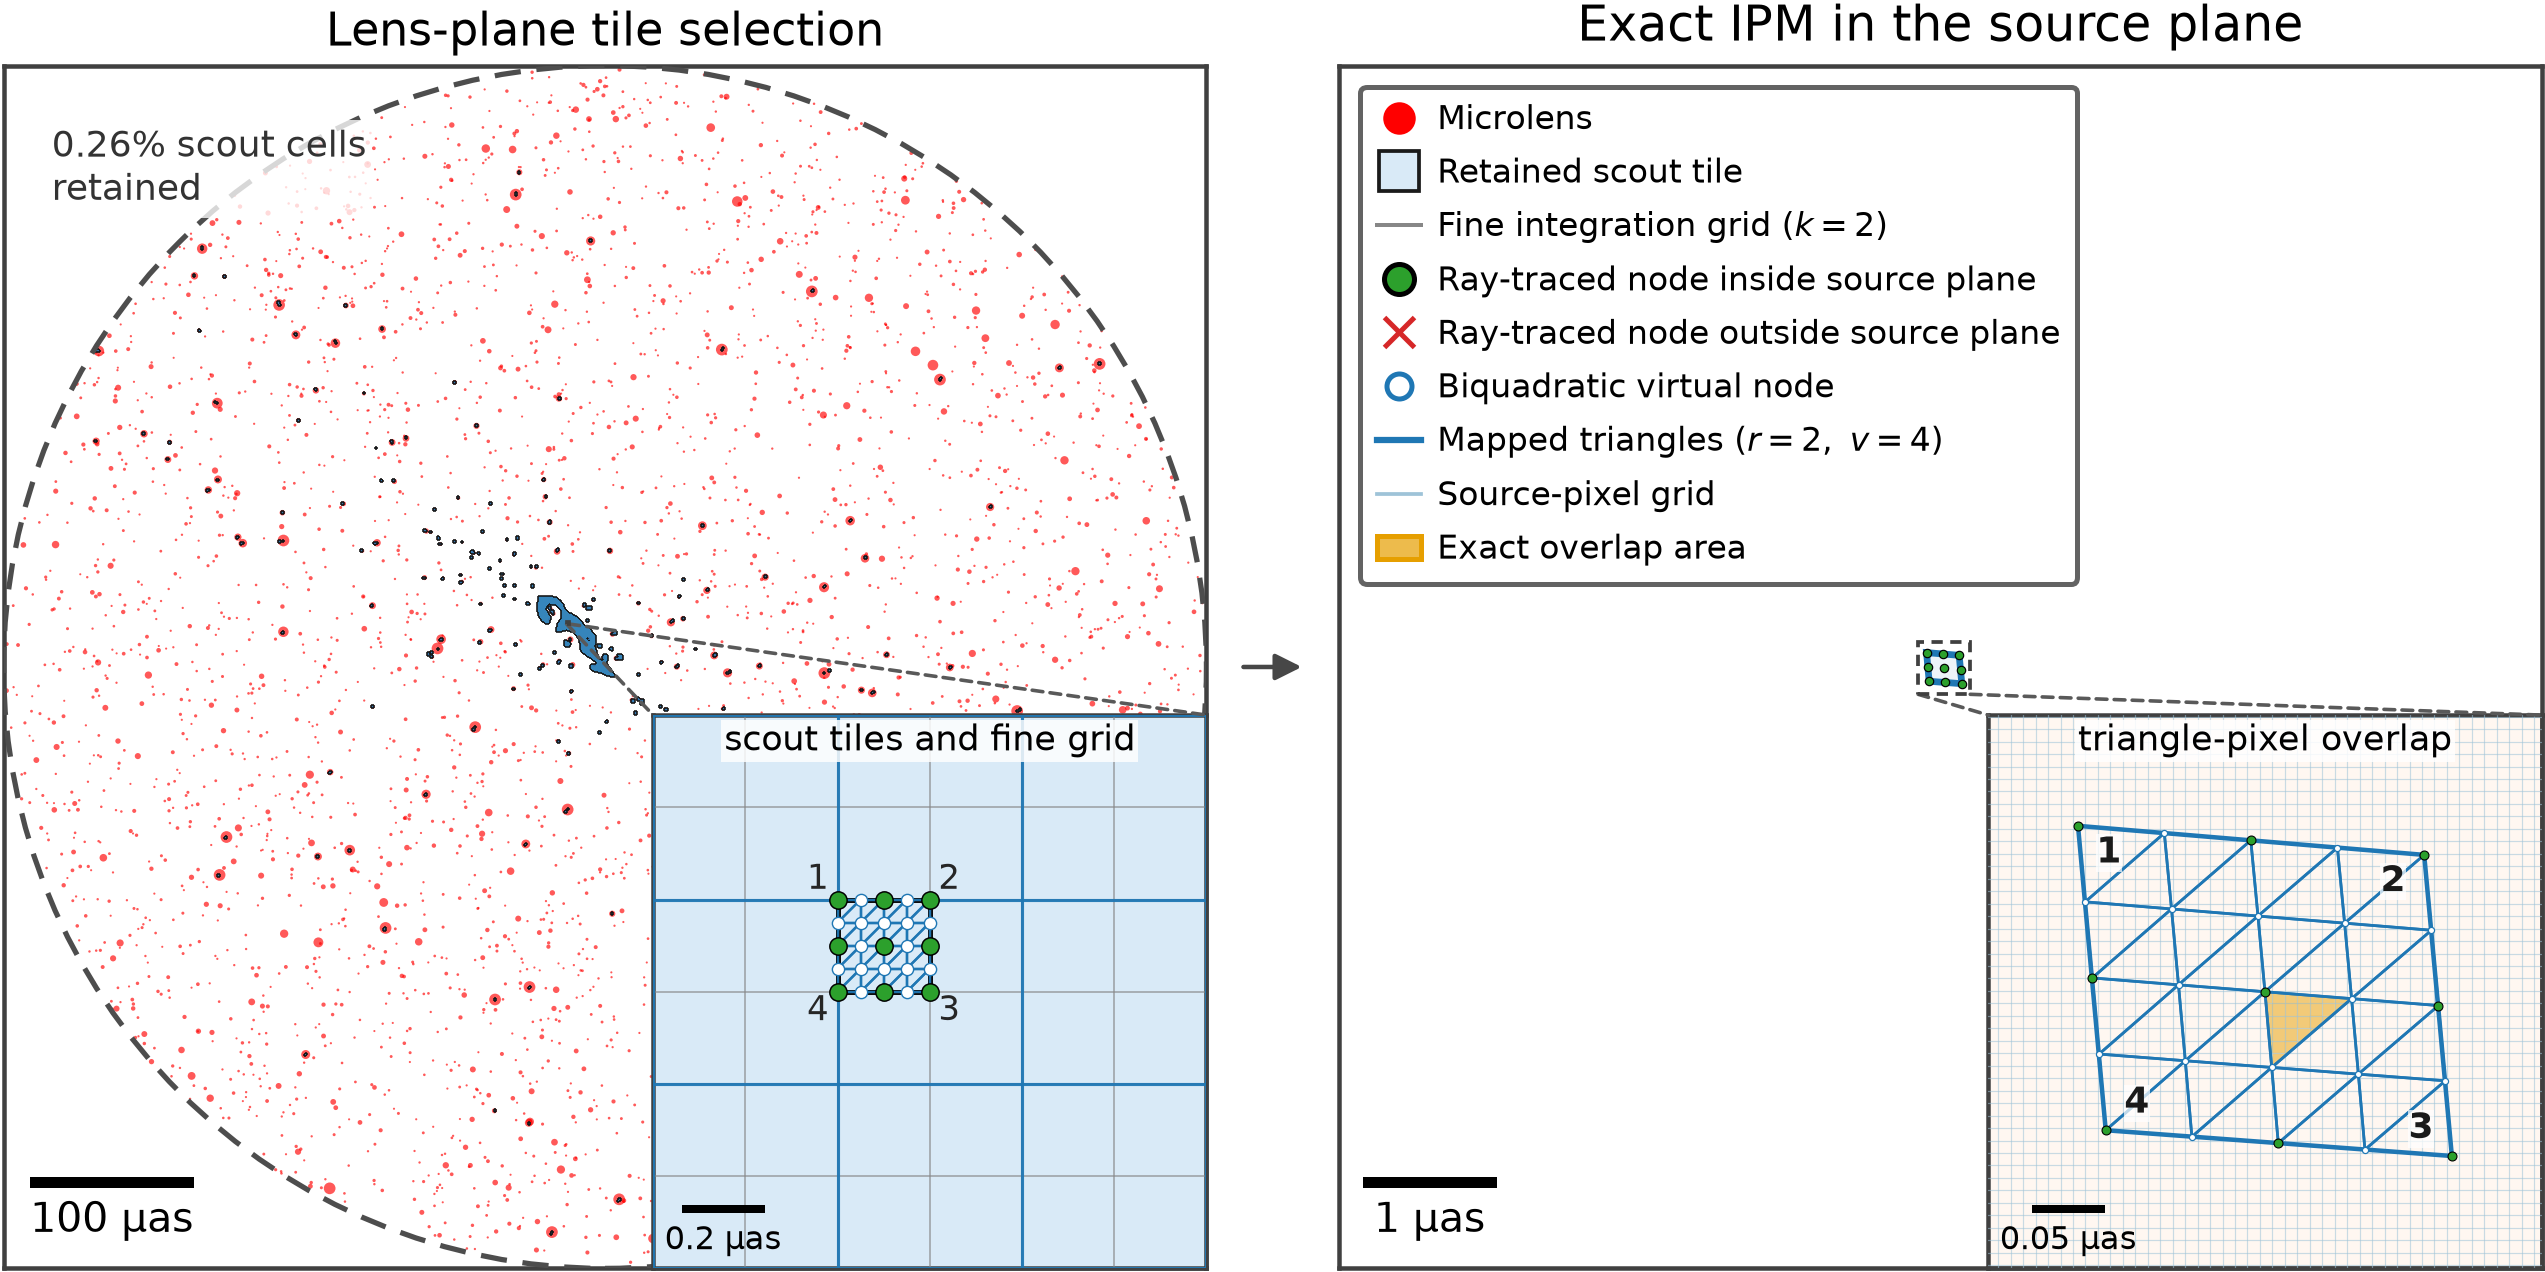

In [6]:
from IPython.display import Image, display

package_root = Path(mcp.__file__).resolve().parents[3]
method_fixtures = package_root / "examples" / "data" / "q2237b_method_figures"
paper_ipm_paths = mcp.render_paper_ipm_schematic(
    method_fixtures / "paper_tile_upsampling_schematic_data.npz",
    method_fixtures / "paper_far_field_schematic_data.npz",
    Path("static_map_tutorial_output"),
    refinement=2,
    virtual_refinement=4,
    source_bins=1024,
    output_prefix="q2237_image_b_scout_and_ipm",
)
display(Image(filename=str(paper_ipm_paths[0])))


## Full and rectangular lens-plane apertures

A rectangular aperture can reduce work when it follows the macro-stretched
preimage of the requested source field. It is not equivalent to the package's
full-star-field tile scout. A rectangle discards cells outside its boundary,
so an insufficient aperture can lose a nearly constant amount of flux or miss
a caustic that enters from outside. The calculation below holds the lens-plane
cell density fixed and changes only the aperture height. Its residual is shown
without subtracting a fitted offset. For an unrelated static map the tiled
alternative should normally start at `k=1`. The dynamic-only `k=1` to `k=2`
normalization repair is intentionally not used here.


Full aperture: 10,000,000 cells; rectangular aperture: 7,000,000 cells at the same nominal density
Raw full-versus-rectangle comparison: MapComparison(linear_nrmse=0.0007618100432614656, fractional_nrmse=7.925975355712881e-05, rmse_mmag=0.08602777421931264, bias_mmag=-2.6189142885145142e-05, p95_absolute_mmag=0.15112858546617372, valid_pixels=1048576)


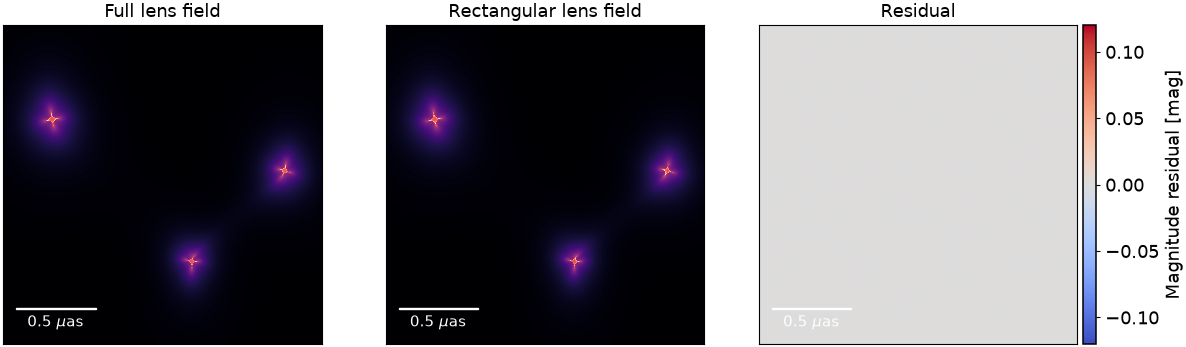

In [7]:
rectangular_region = mc.PlaneRegion((3.5, 5.0))
rectangular_rays = int(round(ipm_rays * 3.5 / 5.0))
rectangular_ipm = simulation.magnification_map(
    rectangular_region,
    grid,
    method=mc.IPMConfig(
        rays=rectangular_rays, refinement=2, virtual_refinement=4,
        tiled=False, far_field_approx=mc.FarFieldApproxConfig(enabled=False),
    ),
)
rectangular_comparison = mc.compare_magnification_maps(
    ipm.values, rectangular_ipm.values,
)
print(
    f"Full aperture: {ipm_rays:,} cells; rectangular aperture: "
    f"{rectangular_rays:,} cells at the same nominal density"
)
print("Raw full-versus-rectangle comparison:", rectangular_comparison)
figure, axes = mcp.plot_map_comparison(
    ipm, rectangular_ipm, residual="magnitude",
    residual_limit=0.12, scale_bar_uas=0.5, show_axes=False,
)
axes[0].set_title("Full lens field")
axes[1].set_title("Rectangular lens field")
axes[2].set_title("Residual")
figure.set_size_inches(12.8, 3.8)
figure.tight_layout()


## Realistic Q2237 B lens-plane strategies

The compact example above isolates the numerical methods. This second example uses a seeded Q2237 image-B-like Salpeter population across the full stellar aperture. Coordinates are rotated into the local shear frame, which leaves the circular stellar realization and source-plane physics unchanged while making the rectangular preimage easy to see. The first row evaluates the real scout and shows exactly which part of the common lens plane each strategy integrates. The second row compares their point-source magnification maps on one registered $1024^2$ grid. For visual map quality, each map receives the same total base-cell budget. This is not a fixed-density timing comparison.


Q2237 B stars: 3805
Full lens FOV [uas]: (754.11, 754.11)
Rectangular preimage FOV [uas]: (106.41554920892948, 488.14472114187845)


Visual fixed-N map times [s] (not a fixed-density timing comparison): {'tiled': 0.6129443000536412, 'full': 0.8191747000091709, 'rectangle': 2.419796700007282}


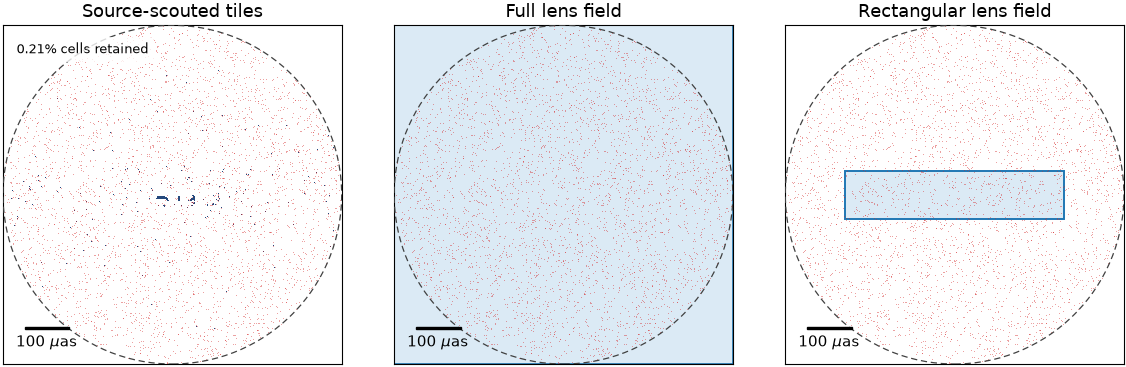

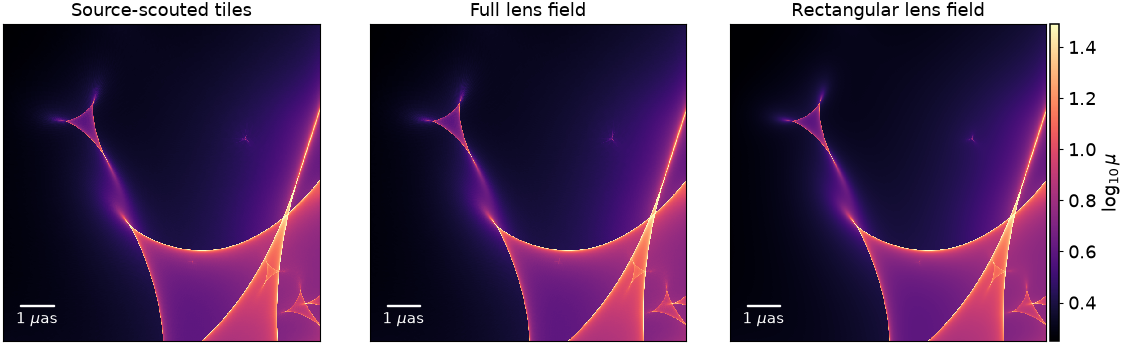

In [8]:
q_distances = mc.LensingDistances.from_redshifts(
    0.0395, 1.695, cosmology=FlatLambdaCDM(H0=70.0, Om0=0.3),
)
q_macro = mc.MacroLens(
    convergence=0.391, shear=0.391, shear_angle_deg=0.0,
    smooth_matter_fraction=0.0,
)
q_lens_diameter = 754.11
q_lens_region = mc.PlaneRegion((q_lens_diameter, q_lens_diameter))
q_radius = 0.5 * q_lens_diameter
q_population = mc.StellarPopulation.salpeter(
    mean_mass_solar=0.3, mass_ratio=100.0,
)
q_mass_function = q_population.mass_function
q_stars = q_population.realize(
    mc.StellarAperture(q_radius), q_macro, q_distances,
    seed=1001, dtype=torch.float64,
)
q_resolution = 1024 if use_cuda else 256
q_source_fov = 9.3819
q_grid = mc.PlaneGrid((q_resolution, q_resolution), (q_source_fov, q_source_fov))
q_system = mc.MicrolensingSystem(
    macro=q_macro, distances=q_distances, stars=q_stars, source_grid=q_grid,
    lens_region=q_lens_region, runtime=runtime_config,
)
q_simulation = q_system.realize().simulation  # plotting helper accepts the resolved tracer
q_rays = 10_000_000 if use_cuda else 262_144
q_tiled_method = mc.production_ipm_config(dynamic=False, rays=q_rays)
q_full_method = mc.IPMConfig(
    rays=q_rays, scout_ratio=1, refinement=2, virtual_refinement=4,
    tiled=False, cell_chunk_size=q_tiled_method.cell_chunk_size,
    far_field_approx=q_tiled_method.far_field_approx,
)
q_rectangle = mc.rectangular_lens_region(
    q_macro, q_grid.region, q_distances, q_mass_function,
    light_loss=0.01,
)
print('Q2237 B stars:', len(q_stars))
print('Full lens FOV [uas]:', q_lens_region.field_of_view_uas)
print('Rectangular preimage FOV [uas]:', q_rectangle.field_of_view_uas)
lens_figure, lens_axes = mcp.plot_lens_field_strategies(
    q_simulation, q_lens_region, q_grid, q_tiled_method, q_rectangle,
    scale_bar_uas=100.0,
)
lens_figure.tight_layout()

q_tiled_map = q_simulation.magnification_map(
    q_lens_region, q_grid, method=q_tiled_method,
)
q_full_map = q_simulation.magnification_map(
    q_lens_region, q_grid, method=q_full_method,
)
q_rectangle_map = q_simulation.magnification_map(
    q_rectangle, q_grid, method=q_full_method,
)
q_logs = [
    np.log10(np.clip(product.values.detach().cpu().numpy(), 1.0e-12, None))
    for product in (q_tiled_map, q_full_map, q_rectangle_map)
]
q_finite = np.concatenate([values[np.isfinite(values)] for values in q_logs])
q_vmin, q_vmax = np.quantile(q_finite, (0.002, 0.998))
map_figure, map_axes = plt.subplots(1, 3, figsize=(11.8, 3.7))
for axis, product, title in zip(
    map_axes, (q_tiled_map, q_full_map, q_rectangle_map),
    ('Source-scouted tiles', 'Full lens field', 'Rectangular lens field'),
    strict=True,
):
    mcp.plot_magnification_map(
        product, ax=axis, colorbar=False, title=title, show_axes=False,
        scale_bar_uas=1.0, vmin=q_vmin, vmax=q_vmax,
    )
mcp.panel_colorbar(
    map_figure, map_axes[-1], map_axes[-1].images[0],
    label=r'$\log_{10}\mu$', size='3%', pad=0.035,
)
map_figure.tight_layout()
print('Visual fixed-N map times [s] (not a fixed-density timing comparison):', {
    'tiled': q_tiled_map.timing.delivered_seconds,
    'full': q_full_map.timing.delivered_seconds,
    'rectangle': q_rectangle_map.timing.delivered_seconds,
})
